In [1]:
%load_ext autoreload
%autoreload 2

# Generación de datos

In [2]:
from instances.instances import generate_instances

instances = generate_instances(filename="TSP50.pkl", instance_count=1000, cities=50, seed=42)

In [3]:
from data.generation import generate_train_data
from data.adapters.input.basic import BasicInputAdapter
from data.adapters.output.basic import BasicOutputAdapter

input_config = (BasicInputAdapter, 50)
output_config = (BasicOutputAdapter, 50)

generate_train_data(
    instance_file="TSP50.pkl", 
    data_filename="train_data.h5", 
    input_adapter_config=input_config, 
    output_adapter_config=output_config,
    num_workers=12,
    size=10000
)

Datos guardados en: /home/oscar/Escritorio/TSP-Framework/data/train_data.h5 (Tamaño: 10000)


# Entrenamiento

In [ ]:
from data.preprocessing import load_dataset

dataset = load_dataset(filepath="train_data.h5")

Dataset train_data.h5 cargado con 10000 muestras.


In [ ]:
from models.glimpse import TSPTransformer

# Parámetros del modelo
input_dim = 2
embed_dim = 64
num_heads = 4
num_encoder_layers = 2
num_glimpses = 2
dropout = 0.1

# Crear modelo
model = TSPTransformer(
    input_dim=input_dim,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_glimpses=num_glimpses,
    dropout_rate=dropout
)

In [ ]:
from training.sl import sl_train, LRConfig
from training.metrics import CrossEntropyLoss, Accuracy

model = sl_train(
    model=model,
    epochs=10,
    dataset=dataset,
    train_size=800,
    test_size=200,
    batch_size=64,
    lr_config=LRConfig(value=1e-4),
    weight_decay=1e-5,
    loss_fn=CrossEntropyLoss(),
    patience=10,
    metrics=[Accuracy()]
)

ℹ️ Usando dispositivo: cpu

Epoch 1/10
    Train CrossEntropy: 3.0116 | Val CrossEntropy: 2.8252
    Accuracy: 36.50%
Epoch 2/10
    Train CrossEntropy: 2.7282 | Val CrossEntropy: 2.0524
    Accuracy: 53.50%
Epoch 3/10
    Train CrossEntropy: 1.9624 | Val CrossEntropy: 1.5677
    Accuracy: 63.50%
Epoch 4/10
    Train CrossEntropy: 1.6980 | Val CrossEntropy: 1.4596
    Accuracy: 63.00%
Epoch 5/10
    Train CrossEntropy: 1.6241 | Val CrossEntropy: 1.3894
    Accuracy: 66.00%
Epoch 6/10
    Train CrossEntropy: 1.5317 | Val CrossEntropy: 1.3382
    Accuracy: 67.50%
Epoch 7/10
    Train CrossEntropy: 1.4682 | Val CrossEntropy: 1.2792
    Accuracy: 68.50%
Epoch 8/10
    Train CrossEntropy: 1.4226 | Val CrossEntropy: 1.2148
    Accuracy: 74.00%
Epoch 9/10
    Train CrossEntropy: 1.3763 | Val CrossEntropy: 1.1636
    Accuracy: 74.50%
Epoch 10/10
    Train CrossEntropy: 1.3231 | Val CrossEntropy: 1.0900
    Accuracy: 77.00%

** Mejor modelo restaurado (Época 10): CrossEntropy = 1.0900


(TSPTransformer(
   (encoder_input_layer): Linear(in_features=2, out_features=64, bias=True)
   (encoder): TransformerEncoder(
     (layers): ModuleList(
       (0-1): 2 x TransformerEncoderLayer(
         (self_attn): MultiheadAttention(
           (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
         )
         (linear1): Linear(in_features=64, out_features=2048, bias=True)
         (dropout): Dropout(p=0.1, inplace=False)
         (linear2): Linear(in_features=2048, out_features=64, bias=True)
         (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
         (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
         (dropout1): Dropout(p=0.1, inplace=False)
         (dropout2): Dropout(p=0.1, inplace=False)
       )
     )
   )
   (ctx_fusion): Linear(in_features=192, out_features=64, bias=True)
   (glimpse_proj): Linear(in_features=64, out_features=64, bias=True)
   (cross_attn): MultiheadAtt

In [7]:
from training.sl import save_model
save_model(model, model_name="model_glimpse")

✅ Modelo guardado en /home/oscar/Escritorio/TSP-Framework/models/model_glimpse.pth


In [11]:
from training.sl import load_model
from models.glimpse import TSPTransformer

model = load_model(TSPTransformer, model_name="model_glimpse")

# Validación

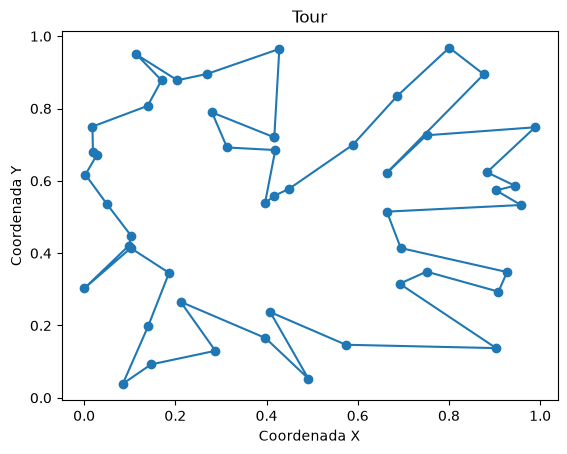

In [ ]:
from src.solvers.model import ModelSolver
from data.adapters.input.basic import BasicInputAdapter

input_adapter = BasicInputAdapter(max_cities=50)
model_solver = ModelSolver(model, input_adapter)
solutions = model_solver.solve("benchmarks/B50.pkl")

solutions[0].plot()

In [10]:
from solvers.eval import evaluate

adapter_config = (BasicInputAdapter, 50)
sols = evaluate(model, "benchmarks/B50.pkl", input_adapter_config=adapter_config, num_workers=12)

Iniciando evaluación de 100 instancias con 12 workers...
** Evaluación completada. Costo promedio: 6.9620
